In [60]:
import numpy as np
import os
import seaborn as sns

In [61]:
data_file='GB_node_array.npy'
if os.path.exists(data_file):
    GB_node_array= np.load(data_file, allow_pickle=True)

In [62]:
class TreeNode:
    def __init__(self, value,qity=None, is_center=True):
        self.value = value  # Center value or leaf value
        self.children = []
        self.qity=qity
        self.is_center = is_center  # To distinguish between center and leaf nodes

    def add_child(self, child_node):
        self.children.append(child_node)
def build_recursive_tree(cluster_data):
    root = TreeNode("Root", is_center=True)  # Root node

    def add_cluster_to_tree(cluster, parent_node):
        center_value,qity = cluster[1]  # Center node value
        center_node = TreeNode(center_value,qity, is_center=True)
        parent_node.add_child(center_node)

        for sub_cluster in cluster[0]:  # Check for sub-clusters
            if isinstance(sub_cluster, tuple):  # If it's a tuple, it's a cluster
                add_cluster_to_tree(sub_cluster, center_node)
            else:  # If it's a node, it's a leaf
                value=sub_cluster[:-1]
                _,qity=sub_cluster[-1]
                leaf_node = TreeNode(value, qity, is_center=False)
                center_node.add_child(leaf_node)

    for cluster in cluster_data:
        add_cluster_to_tree(cluster, root)

    return root

In [63]:
GB_node_list = [tuple(item) for item in GB_node_array]

tree = build_recursive_tree(GB_node_list)

In [64]:
GB_flatten=[]

In [65]:
def flatten__tree(node, centers=[]):
    #print(" " * level + str(node.value))  # Print node value
    if isinstance(node.value, list):
        GB_flatten.append((node.value, centers+[(None,node.qity)]))
    else:
        for child in node.children:
            flatten__tree(child, centers+[(node.value, node.qity)])

In [66]:
flatten__tree(tree)

In [83]:
GB_flatten[9][1:]

([('Root', None), (526, 0.4279484), (792, 0.875), (None, 0.875)],)

In [68]:
GB_node_len_orin=[len(GB[0]) for GB in GB_flatten]

In [69]:
sorted(GB_node_len_orin, reverse=True)

[4550,
 4019,
 3787,
 3776,
 3773,
 3766,
 3711,
 3675,
 3649,
 3645,
 3634,
 3589,
 3584,
 3573,
 3566,
 3565,
 3560,
 3559,
 3549,
 3544,
 3537,
 3535,
 3529,
 3520,
 3515,
 3515,
 3514,
 3512,
 3510,
 3509,
 3507,
 3506,
 3503,
 3492,
 3487,
 3479,
 3478,
 3472,
 3463,
 3462,
 3461,
 3457,
 3455,
 3455,
 3452,
 3451,
 3450,
 3449,
 3446,
 3445,
 3443,
 3437,
 3436,
 3433,
 3428,
 3425,
 3424,
 3420,
 3415,
 3412,
 3407,
 3405,
 3394,
 3389,
 3385,
 3381,
 3368,
 3366,
 3364,
 3363,
 3363,
 3362,
 3358,
 3356,
 3356,
 3354,
 3350,
 3347,
 3346,
 3345,
 3345,
 3327,
 3320,
 3315,
 3309,
 3302,
 3299,
 3297,
 3293,
 3285,
 3283,
 3282,
 3271,
 3259,
 3252,
 3249,
 3247,
 3240,
 3220,
 3206,
 3196,
 3193,
 3182,
 3180,
 3176,
 3166,
 3146,
 3144,
 3127,
 3126,
 3112,
 3095,
 3092,
 3085,
 3080,
 3079,
 3071,
 3062,
 3059,
 3057,
 3053,
 3041,
 3032,
 3032,
 3021,
 3009,
 2992,
 2982,
 2979,
 2976,
 2973,
 2971,
 2964,
 2961,
 2956,
 2954,
 2951,
 2951,
 2948,
 2944,
 2939,
 2936,
 2933,

In [70]:
GB_node_len=[len([node for node in GB[0] if node<1892]) for GB in GB_flatten]

In [71]:
len(GB_node_len)

510

In [72]:
sum(GB_node_len)

1892

In [73]:
sorted(GB_node_len, reverse=True)

[29,
 21,
 20,
 19,
 18,
 17,
 15,
 14,
 13,
 13,
 12,
 12,
 12,
 11,
 11,
 11,
 10,
 10,
 10,
 10,
 9,
 9,
 9,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,


<AxesSubplot:ylabel='Count'>

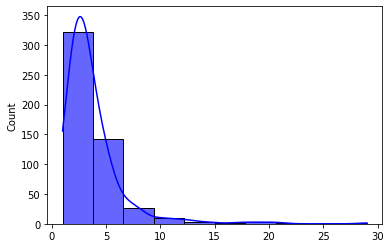

In [74]:
sns.histplot(GB_node_len, bins=10, kde=True, color='blue', alpha=0.6)

<AxesSubplot:ylabel='Count'>

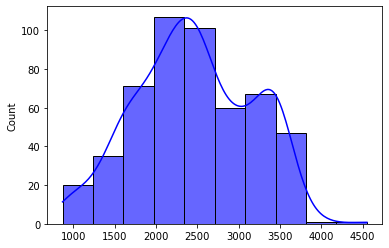

In [21]:
sns.histplot(GB_node_len_orin, bins=10, kde=True, color='blue', alpha=0.6)

In [22]:
len(GB_node_len)

510

In [23]:
len(GB_node_len)

510

In [24]:
max(GB_node_len)

29

In [14]:
len(GB_node_array[1][0])

2

In [15]:
len([length for length in GB_node_len if length==2])

7

In [16]:
GB_node_array[1][0][1]

([[9733,
   5638,
   6151,
   16391,
   3081,
   7177,
   7180,
   12304,
   10256,
   11793,
   534,
   22,
   7706,
   14362,
   14879,
   9761,
   34,
   7715,
   1573,
   8236,
   2095,
   6201,
   7225,
   11323,
   4159,
   3141,
   6732,
   11349,
   12903,
   12394,
   8811,
   4718,
   14967,
   631,
   10370,
   8324,
   1673,
   12430,
   5777,
   9361,
   8340,
   12438,
   3229,
   6304,
   3233,
   10403,
   2216,
   1196,
   1718,
   1208,
   10432,
   7363,
   12997,
   3790,
   6867,
   15573,
   731,
   3291,
   6880,
   14051,
   16612,
   13032,
   17148,
   258,
   9989,
   2314,
   5387,
   10002,
   13592,
   7450,
   11035,
   7973,
   1836,
   16190,
   1856,
   4417,
   3394,
   327,
   9032,
   841,
   2890,
   10571,
   12616,
   14151,
   13141,
   5975,
   2395,
   10086,
   10600,
   17256,
   3434,
   17259,
   14191,
   9586,
   373,
   10106,
   14204,
   13183,
   6529,
   387,
   390,
   6541,
   10639,
   8597,
   14745,
   8603,
   15260,
   4513,
